In [ ]:
!pip install qiskit qiskit-aer scipy

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import pandas as pd

simulator = AerSimulator()

shot_list = [100, 1000, 10000]
data = []

for shots in shot_list:

    qc = QuantumCircuit(1, 1)

    # Create superposition
    qc.h(0)

    # Measure qubit
    qc.measure(0, 0)

    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()

    zero = counts.get('0', 0)
    one = counts.get('1', 0)

    p_zero = zero / shots
    p_one = one / shots

    data.append([
        shots,
        zero,
        one,
        p_zero,
        p_one
    ])

# Display results as table
df = pd.DataFrame(
    data,
    columns=[
        "Shots",
        "0 Count",
        "1 Count",
        "Probability of 0",
        "Probability of 1"
    ]
)

print(df)



   Shots  0 Count  1 Count  Probability of 0  Probability of 1
0    100       53       47            0.5300            0.4700
1   1000      493      507            0.4930            0.5070
2  10000     5106     4894            0.5106            0.4894


|+> Measurement:
{'0': 1024}

|-> Measurement:
{'1': 1024}


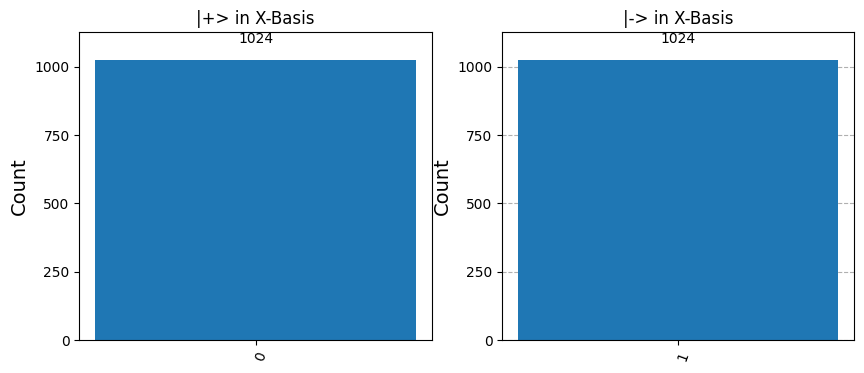

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

simulator = AerSimulator()

# -----------------------------
# Prepare |+> state
# -----------------------------

plus = QuantumCircuit(1, 1)

plus.h(0)

# H before measurement = X-basis measurement
plus.h(0)
plus.measure(0, 0)

result_plus = simulator.run(
    plus,
    shots=1024
).result()

counts_plus = result_plus.get_counts()

print("|+> Measurement:")
print(counts_plus)


# -----------------------------
# Prepare |-> state
# -----------------------------

minus = QuantumCircuit(1, 1)

minus.x(0)
minus.h(0)

# X-basis measurement
minus.h(0)
minus.measure(0, 0)

result_minus = simulator.run(
    minus,
    shots=1024
).result()

counts_minus = result_minus.get_counts()

print("\n|-> Measurement:")
print(counts_minus)


# -----------------------------
# Display histograms
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_histogram(counts_plus, ax=axes[0])
axes[0].set_title("|+> in X-Basis")

plot_histogram(counts_minus, ax=axes[1])
axes[1].set_title("|-> in X-Basis")

plt.show()

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Create 2 qubits and 1 classical bit
qc = QuantumCircuit(2, 1)

# Create Bell state
qc.h(0)
qc.cx(0, 1)

# Measure only qubit 0
qc.measure(0, 0)

print("Partial Measurement Bell Circuit:")
print(qc.draw())

# Simulator
simulator = AerSimulator()

result = simulator.run(
    qc,
    shots=1024
).result()

counts = result.get_counts()

print("\nMeasurement Results:")
print(counts)

# Calculate probabilities
zero = counts.get('0', 0)
one = counts.get('1', 0)

print("\nProbability of measuring 0:",
      zero / 1024)

print("Probability of measuring 1:",
      one / 1024)

Partial Measurement Bell Circuit:
     ┌───┐     ┌─┐
q_0: ┤ H ├──■──┤M├
     └───┘┌─┴─┐└╥┘
q_1: ─────┤ X ├─╫─
          └───┘ ║ 
c: 1/═══════════╩═
                0 

Measurement Results:
{'1': 532, '0': 492}

Probability of measuring 0: 0.48046875
Probability of measuring 1: 0.51953125


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

simulator = AerSimulator()

# Unknown rotation angle
actual_angle = 0.8

# Create circuit
qc = QuantumCircuit(1, 1)

# Apply unknown Y rotation
qc.ry(actual_angle, 0)

# Measure qubit
qc.measure(0, 0)

# Number of shots
shots = 10000

# Run circuit
result = simulator.run(
    qc,
    shots=shots
).result()

counts = result.get_counts()

print("Measurement Counts:")
print(counts)

# Probability of getting 1
p1 = counts.get('1', 0) / shots

print("\nMeasured P(1):", p1)

# For RY(theta):
# P(1) = sin²(theta/2)

estimated_angle = 2 * np.arcsin(np.sqrt(p1))

print("\nActual Angle:", actual_angle)
print("Estimated Angle:", estimated_angle)

print("\nError:",
      abs(actual_angle - estimated_angle))

Measurement Counts:
{'1': 1526, '0': 8474}

Measured P(1): 0.1526

Actual Angle: 0.8
Estimated Angle: 0.8026545489637941

Error: 0.0026545489637940234
